# Exporting Land Cover data in table format <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with the `DEA Sandbox` environment
* **Products used:** 
[ga_ls_landcover_class_cyear_3](https://explorer.dea.ga.gov.au/products/ga_ls_landcover_class_cyear_3)

## Background 
Land cover is the physical surface of the Earth, including trees, shrubs, grasses, soils, exposed rocks, water bodies, plantations, crops and built structures.

Digital Earth Australia Land Cover (DEA Land Cover) is a continental dataset that maps annual land cover classifications for Australia from 1988 to the present. 
Detailed information about DEA Land Cover can be found in the [DEA Land Cover notebook](../DEA_products/DEA_Land_Cover.ipynb) and on the [DEA Land Cover product details](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat) page.

## Description 

This notebook will demonstrate how to export data from the [DEA Land Cover](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat) for facilitating quantitative analyses. 

Topics include: 

1. Select an area and time range of interest and load the Land Cover data cube
2. Define a DEA Land Cover level and classes of interest
3. For each year, extract the number of pixels of each class of interest, together with the extent of those classes in squared metres, squared kilometres and hectars
4. Save the extracted data as a CSV file for potential further analyses
5. Examples of data visualisation
6. Use a shapefile to further refine the area of interest

This notebook requires a basic understanding of the DEA Land Cover data set. 
If you are new to DEA Land Cover, it is recommended you first look at the following notebooks: [DEA_Land_Cover](../DEA_products/DEA_Land_Cover.ipynb), [Land_cover_pixel_drill](../How_to_guides/Land_cover_pixel_drill.ipynb).

***

## Getting started

Import the Python packages needed to run this notebook, connect to the datacube, define custom functions that we will need later in the notebook

### Load packages

In [1]:
%matplotlib inline
import sys 
import os

import datacube
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(1, os.path.abspath("../Tools"))
from dea_tools.plotting import display_map
from dea_tools.landcover import get_label, plot_land_cover

### Connect to the datacube
Connect to the datacube so we can access DEA data. 

In [2]:
dc = datacube.Datacube(app="Land_cover_extract_data")

### Define custom functions

The following function allows to count how many pixels of the classes of interest are contained in a ROI. It then converts the number of pixels into squared metres, squared kilometres, and hectares. It also records the total number of pixels within the ROI.

In [3]:
def extract_data_from_roi(lc_ds,
                          spatial_res,
                          ROI_name,
                          lc_level,
                          classes_list='all'):
    '''
    Count pixels of classes of interest within ROI for every year,
    and convert them into m2, km2, ha.
    
    Parameters
    -------------------------
    lc_ds : xarray.DataArray
        A data cube containing the DEA Land Cover.
    spatial_res : int
        the spatial resolution of the data cube 
    ROI_name : string
        an ID for the area of interest
    lc_level : string
        the land cover level. Either 'level3', 'level4'
    classes_list : list of int, or 'all' (string)
        either a list of values of LC classes of interest, 
        or 'all' for including every class present in the ROI

    Returns
    -------------------------
    Pandas dataframe with the count of pixels and area extent
    for each class of interest and each year in the input data cube
    '''

    #create output df
    out_columns = [
        'ROI_name', 'year', 'tot_pixels', 'lc_level', 'class_value',
        'class_label', 'class_pixels', 'area_m2', 'area_km2', 'ha'
    ]
    out_df = pd.DataFrame(columns=out_columns)
    out_df_row = 0  # this is the starting row to use for populating the output df

    # if selected 'all', modify list to contain all the classes present within the ROI
    if classes_list == 'all':
        classes_list = np.unique(lc_ds[lc_level].values)

    # iterate over all years available
    print('Adding data to the output table...')
    for t in lc_ds.time:
        # select a single year
        lc_df_y = lc_ds.sel(time=t)
        # count the total number of pixels
        tot_px = lc_df_y[lc_level].size

        # iterate over the classes of interest
        for class_value in classes_list:

            # count the pixels of the class of interest
            px_count = np.nansum(lc_df_y[lc_level] == class_value)
            # convert into squared metres
            metre_sq = px_count * (spatial_res**2)
            # convert into squared km
            km_sq = metre_sq / 1000000
            # convert into hectares
            ha = metre_sq / 10000

            # populate the dataframe
            out_df.loc[out_df_row, 'ROI_name'] = ROI_name
            out_df.loc[out_df_row, 'year'] = pd.to_datetime(
                t.values
            ).year  #convert date value into datetime and then extract the year
            out_df.loc[out_df_row, 'tot_pixels'] = tot_px
            out_df.loc[out_df_row, 'lc_level'] = lc_level
            out_df.loc[out_df_row, 'class_value'] = class_value
            out_df.loc[out_df_row,
                       'class_label'] = get_label(class_value, lc_level)
            out_df.loc[out_df_row, 'class_pixels'] = px_count
            out_df.loc[out_df_row, 'area_m2'] = metre_sq
            out_df.loc[out_df_row, 'area_km2'] = km_sq
            out_df.loc[out_df_row, 'ha'] = ha

            # increase output df row where to save output (i.e. get to next empty row)
            out_df_row += 1

    # sort data frame by class value and then year
    out_df_sorted = out_df.sort_values(by=['class_value', 'year']).reset_index(
        drop=True)

    print('Done!')

    return out_df_sorted

## Define area and time range of interest and load data

In [4]:
# Coordinates for Quinns Rocks, Western Australia
lat = -31.668
lon = 115.7
lat_buffer = 0.05
lon_buffer = 0.05

# Combine central coordinates with buffer values to create the latitude and longitude range for the analysis
lat_range = (lat - lat_buffer, lat + lat_buffer)
lon_range = (lon - lon_buffer, lon + lon_buffer)

# Display area on map
display_map(x=lon_range, y=lat_range)

In [5]:
# Provide further information needed for loading the data and for the subsequent data extraction

# Provide an ID for the area of interest
ROI_id = "QuinnsRocks_WA"

# Set the range of dates for the analysis
time_range = ("2000", "2023")

# Set spatial resolution (the native resolution of the LC product is 30m)
res = 30

In [6]:
# Create the 'query' dictionary object, which contains the coordinates defined above
query = {
    "y": lat_range,
    "x": lon_range,
    "time": time_range,
}

# Load DEA Land Cover data from the datacube
lc_ds = dc.load(product="ga_ls_landcover_class_cyear_3",
                output_crs="EPSG:3577",
                measurements=["level3","level4"],
                resolution=(-res, res),
                **query)

In [7]:
# Have a look at the data we loaded
lc_ds

<xarray.Dataset> Size: 7MB
Dimensions:      (time: 24, y: 411, x: 359)
Coordinates:
  * time         (time) datetime64[ns] 192B 2000-07-01T23:59:59.999999 ... 20...
  * y            (y) float64 3kB -3.542e+06 -3.542e+06 ... -3.554e+06 -3.554e+06
  * x            (x) float64 3kB -1.533e+06 -1.533e+06 ... -1.522e+06 -1.522e+06
    spatial_ref  int32 4B 3577
Data variables:
    level3       (time, y, x) uint8 4MB 220 220 220 220 220 ... 215 215 215 215
    level4       (time, y, x) uint8 4MB 101 101 102 101 101 ... 93 93 93 93 93
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

## Define the Land Cover classes of interest and extract the data

We will define the Land Cover level of interest, as well the specific classes we want to include in the output table. For this exercise, we will focus on Natural Terrestrial Vegetation (NTV), Artificial Surface (AS), and Natural Bare Surface (NS)

To select the classes values corresponding to the land cover type of interest, please refer to the [DEA Knowledge Hub](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat/?tab=description#technical-information).

It is also possible to count every class present in the ROI, by assigning "all" to the variable classes_list in the following code cell.

In [8]:
# Indicate the land cover level of interest (either "level3" or "level4")
lc_level = "level3"

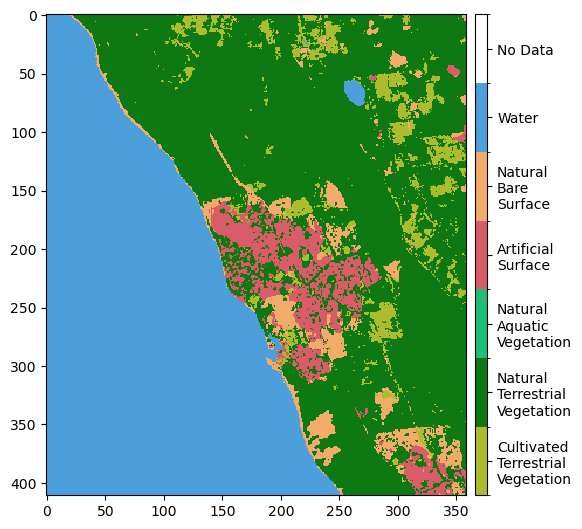

In [9]:
# visualise land cover of the first year...
plot_land_cover(lc_ds[lc_level], year=time_range[0], out_width=6)

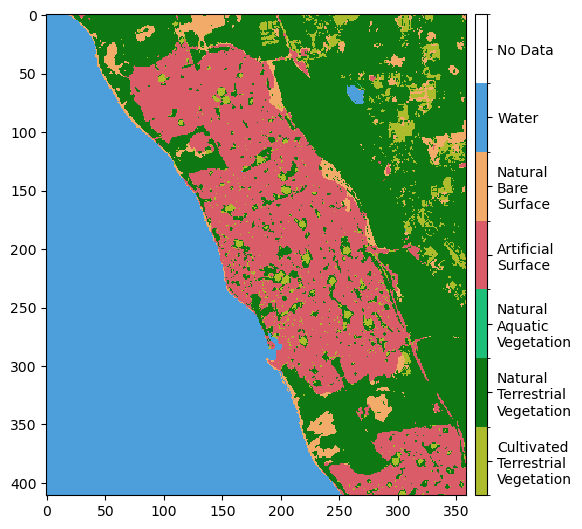

In [10]:
# ..and last year
plot_land_cover(lc_ds[lc_level], year=time_range[-1], out_width=6)

In [11]:
# after looking at the DEA Knowledge Hub, we identified that level3 NTV is value 112, AS is 215, NS is 216
classes_list = [112, 215, 216]

In [12]:
# extract the data using the function defined above and save the output table to a new variable
df = extract_data_from_roi(lc_ds,res,ROI_id,lc_level,classes_list=classes_list)

Adding data to the output table...
Done!


In [13]:
# visualise the output table
df

,ROI_name,year,tot_pixels,lc_level,class_value,class_label,class_pixels,area_m2,area_km2,ha
0,QuinnsRocks_WA,2000,147549,level3,112,Natural Terrestrial Vegetation,67034,60330600,60.3306,6033.06
1,QuinnsRocks_WA,2001,147549,level3,112,Natural Terrestrial Vegetation,56975,51277500,51.2775,5127.75
2,QuinnsRocks_WA,2002,147549,level3,112,Natural Terrestrial Vegetation,59118,53206200,53.2062,5320.62
3,QuinnsRocks_WA,2003,147549,level3,112,Natural Terrestrial Vegetation,61602,55441800,55.4418,5544.18
4,QuinnsRocks_WA,2004,147549,level3,112,Natural Terrestrial Vegetation,57029,51326100,51.3261,5132.61
...,...,...,...,...,...,...,...,...,...,...
67,QuinnsRocks_WA,2019,147549,level3,216,Natural Bare Surface,3417,3075300,3.0753,307.53
68,QuinnsRocks_WA,2020,147549,level3,216,Natural Bare Surface,5119,4607100,4.6071,460.71
69,QuinnsRocks_WA,2021,147549,level3,216,Natural Bare Surface,4417,3975300,3.9753,397.53
70,QuinnsRocks_WA,2022,147549,level3,216,Natural Bare Surface,5082,4573800,4.5738,457.38


## Save the output table into a CSV that can be used for further analyses

In [14]:
df.to_csv(f'count_pixels_and_area_{ROI_id}.csv', index=False) # do not include Pandas index in the output

## Some examples of further analysis

Once the data is extracted and stored in a table format, we can use it for several different analyses. The following are some examples of possible data visualisation to help interpreting the data.

### Time series

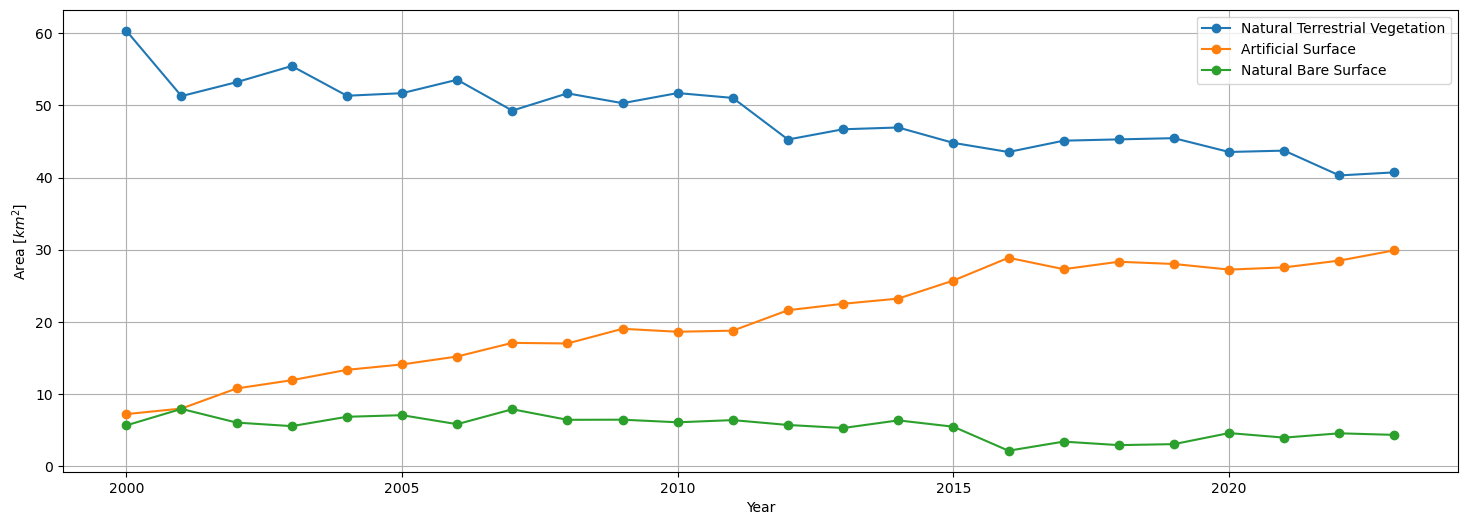

In [15]:
plt.figure(figsize=(18,6))

for label in df['class_label'].unique(): # iterate over each land cover class in df
    subset = df.loc[df['class_label'] == label] # select rows corresponding to current class
    plt.plot(subset['year'], subset['area_km2'], marker='o', label=label) # add line plot for that class

# add axes labels and legend to the chart
plt.xlabel('Year')
plt.ylabel('Area [$km^2$]')
plt.legend()
plt.grid(True)
plt.show()

### Stacked bar chart

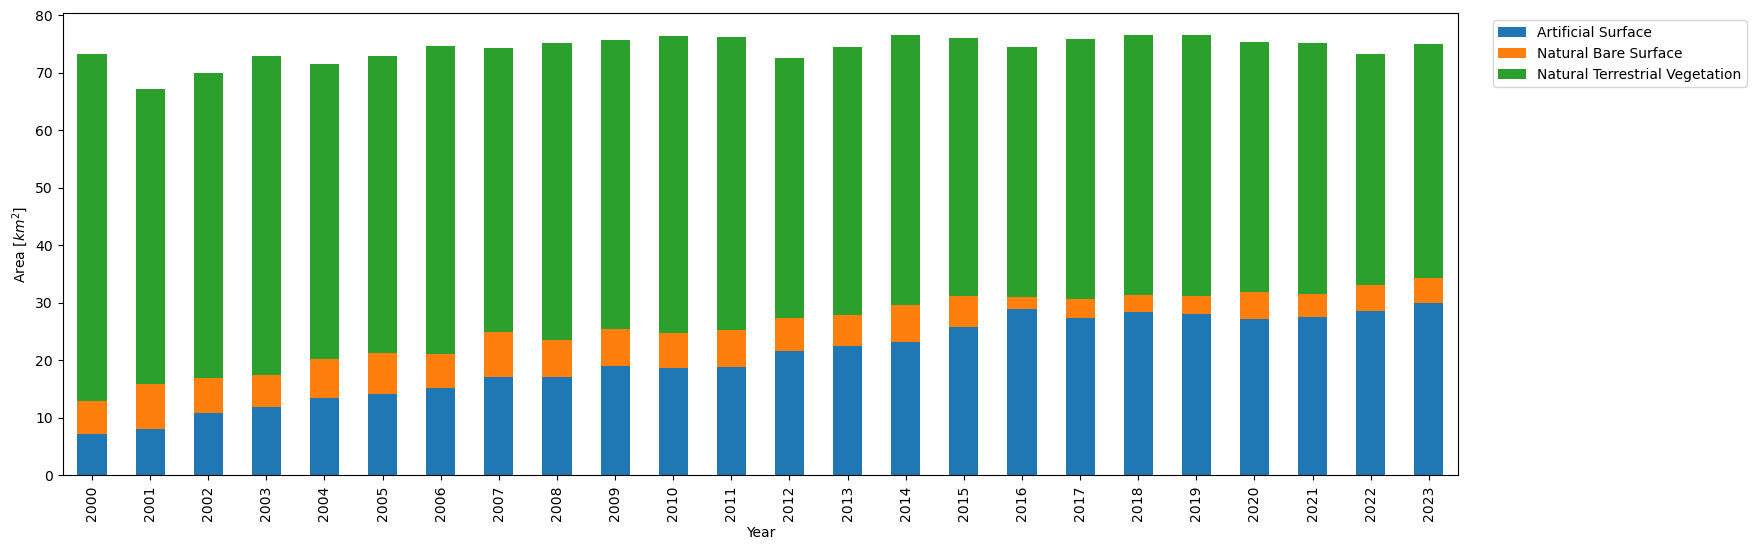

In [29]:
# transform the dataset so that we have a column for each class,
# rather than having all the classes distributed across the rows of the same column
pivot_df = df.pivot_table(index='year', # use year as index for the rows,
                          columns='class_label', # and the unique classes labels as columns
                          values='area_km2')  # finally, populate the table with the area values for each year and class

pivot_df.plot(kind='bar', stacked=True, figsize=(18, 6))

plt.xlabel('Year')
plt.ylabel('Area [$km^2$]')
# move legend outside the chart
plt.legend(bbox_to_anchor=(1.02, 1),
           loc='upper left') 
plt.show()

## Use a shapefile to further refine the area of interest

In [ ]:
# NEED TO ADD MASK INPUT IN FUNCTION AT THE BEGINNING

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** March 2025

**Compatible datacube version:** 

In [76]:
print(datacube.__version__)

1.8.19
